# 01 · Data Prep & Profile

**The question this notebook answers:** what does the dataset actually give us, and what are its
limits, before any activation / engagement / retention / value analysis is built on it?

**Grain:** one row = one *enrollment* = one (subject, semester, student) triple. A student
who retakes a subject contributes a second enrollment — flagged below, not deduplicated.

**Disclosure:** this project uses **OULAD** (Open University Learning Analytics Dataset) — real,
anonymised UK university data, CC BY 4.0. It has **no monetization stage** — it's a free
platform. Wherever this project's stages map onto money, it uses `final_result` as a labelled
**value-outcome proxy** (did the learner get what they came for), never called revenue. Full
reasoning for the dataset choice is in `../ADR.md`; data provenance is in `data/README.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import prep
from viz_style import set_style, savefig, CATEGORICAL, RESULT_ORDER, RESULT_COLORS

set_style()
pd.set_option("display.max_columns", 50)


## Scale

How many enrollments, students, and course runs are actually here.

In [2]:
raw = prep.load_raw()
enr = prep.build_enrollments(raw)

n_students = enr["id_student"].nunique()
n_presentations = enr[prep.PRESENTATION_KEY].drop_duplicates().shape[0]

print(f"enrollments (subject x semester x student):     {len(enr):,}")
print(f"distinct students:                              {n_students:,}")
print(f"distinct course runs:                           {n_presentations}")
print(f"distinct subjects (code_module):                {enr['code_module'].nunique()}")

enrollments (subject x semester x student):     32,593
distinct students:                              28,785
distinct course runs:                           22
distinct subjects (code_module):                7


**[OBS]** 32,593 enrollments across 28,785 distinct students and 22 course runs
(7 subjects × up to 4 semesters each). This is a real, moderately-sized sample — enough for
cohort comparisons across 22 groups, though any single course-run cell (down to ~1,000
students, see below) should be read as a modest sample, not a large one.

## Coverage window — relative days, not calendar time

This is the first real limitation: time in this dataset is *days relative to each course's own start date* (day 0), not a shared calendar. There is no single "month 1 vs month 2" the way a SaaS product's calendar cohorts would work — cohorts here are the 22 course runs themselves, run at 4 different real-world semesters (2013B/J, 2014B/J).

In [3]:
courses = raw["courses"].sort_values("code_presentation")
display(courses)

print(f"\ncourse-run length ranges {courses['module_presentation_length'].min()}"
      f"-{courses['module_presentation_length'].max()} days")
print(f"registered before day 0: {enr['registered_before_start'].mean():.1%} of enrollments")
print(f"missing date_registration: {enr['date_registration'].isna().sum()} enrollments")

,code_module,code_presentation,module_presentation_length
10,DDD,2013B,240
17,FFF,2013B,240
4,BBB,2013B,240
19,GGG,2013J,261
15,FFF,2013J,268
12,EEE,2013J,268
8,DDD,2013J,261
0,AAA,2013J,268
2,BBB,2013J,268
11,DDD,2014B,241



course-run length ranges 234-269 days
registered before day 0: 99.1% of enrollments
missing date_registration: 45 enrollments


**[OBS]** 99.1% of enrollments have a registration date before the course's day 0. Signup-to-outcome
is observable for nearly everyone, which is what makes an activation analysis meaningful. 45
enrollments (0.1%) have no registration date and are excluded from any registration-timing
analysis.

## Cohort sizes by semester

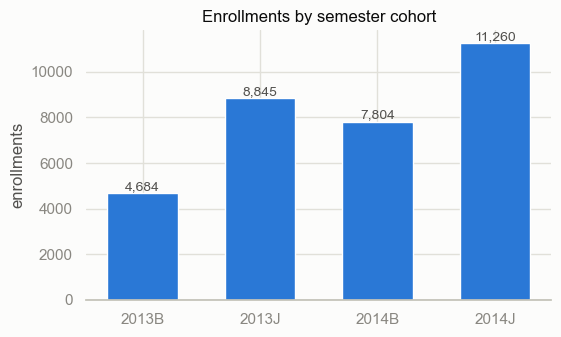

In [4]:
by_pres = enr.groupby("code_presentation").size().reindex(["2013B", "2013J", "2014B", "2014J"])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(by_pres.index, by_pres.values, color=CATEGORICAL[0], width=0.6)
for i, v in enumerate(by_pres.values):
    ax.text(i, v + 150, f"{v:,}", ha="center", color="#52514e", fontsize=10)
ax.set_ylabel("enrollments")
ax.set_title("Enrollments by semester cohort")
sns.despine(left=True)
ax.grid(axis="x")
savefig("01_cohort_sizes")
plt.show()


## Outcome distribution — the value-outcome proxy

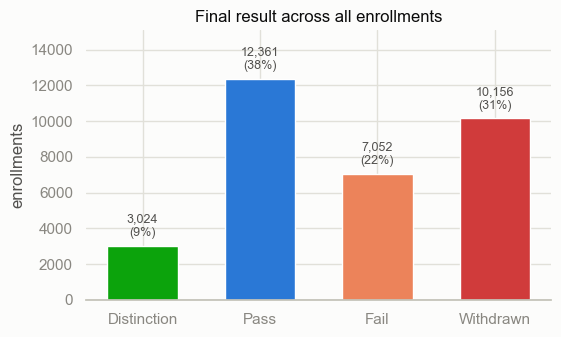

In [5]:
counts = enr["final_result"].value_counts().reindex(RESULT_ORDER)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(counts.index, counts.values, color=[RESULT_COLORS[r] for r in RESULT_ORDER], width=0.6)
ax.set_ylim(0, counts.max() * 1.22)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.03, f"{v:,}\n({v/len(enr):.0%})",
             ha="center", va="bottom", color="#52514e", fontsize=9)
ax.set_ylabel("enrollments")
ax.set_title("Final result across all enrollments")
sns.despine(left=True)
ax.grid(axis="x")
savefig("01_outcome_distribution")
plt.show()


**[OBS]** 47.2% of enrollments end in Pass or Distinction ("success" throughout this project);
30.9% end in Withdrawn; 21.6% in Fail. Withdrawn and Fail are kept separate throughout — a
student who withdrew made an active exit decision (has a `date_unregistration`), which is a
different signal from a student who stayed enrolled and failed.


## Subject heterogeneity — why subjects can't be pooled blindly

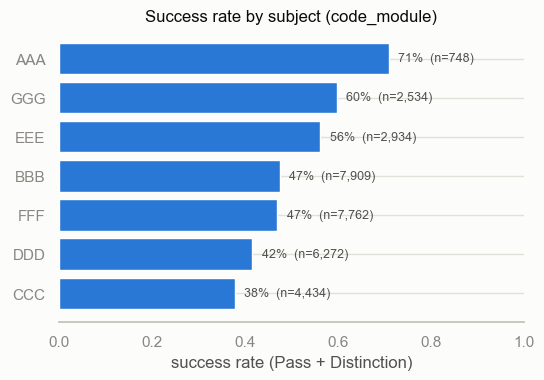

In [6]:
by_module = enr.groupby("code_module")["success"].agg(["mean", "size"]).sort_values("mean")
by_module.columns = ["success_rate", "n_enrollments"]

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh(by_module.index, by_module["success_rate"], color=CATEGORICAL[0])
ax.set_xlabel("success rate (Pass + Distinction)")
ax.set_title("Success rate by subject (code_module)")
ax.set_xlim(0, 1)
for i, (rate, n) in enumerate(zip(by_module["success_rate"], by_module["n_enrollments"])):
    ax.text(rate + 0.02, i, f"{rate:.0%}  (n={n:,})", va="center", color="#52514e", fontsize=9)
sns.despine(left=True)
savefig("01_success_by_module")
plt.show()


**[OBS]** Success rate ranges from 37.8% (subject CCC) to 71.0% (subject AAA) — a 33-point spread
across subjects. **[HYP]** This is very likely subject difficulty/structure, not a real
difference in the student populations, though it's also consistent with different subjects
attracting different students; both can be true at once. **Consequence for every later
notebook:** any activation/engagement finding must be checked within subject, not just pooled
across all 22 course runs, or a subject-mix shift could be mistaken for a behavioural effect
(rate vs. mix).

## Non-independence: students who appear more than once

In [7]:
n_multi_students = enr.loc[enr["multi_enrollment_student"], "id_student"].nunique()
n_multi_enrollments = enr["multi_enrollment_student"].sum()

print(f"students who appear more than once (any subject, any semester): {n_multi_students:,} "
      f"({n_multi_students/n_students:.1%} of students)")
print(f"enrollments belonging to one of these students:                 {n_multi_enrollments:,} "
      f"({n_multi_enrollments/len(enr):.1%} of enrollments)")

# a genuine retake = same student, same subject, more than once (a narrower, different question)
retakes_per_subject = enr.groupby(["id_student", "code_module"]).size()
same_subject_retake_students = (
    retakes_per_subject[retakes_per_subject > 1].index.get_level_values("id_student").nunique()
)
print()
print(f"of those, students who genuinely retook the same subject:       {same_subject_retake_students:,} "
      f"({same_subject_retake_students/n_students:.1%} of students)")

students who appear more than once (any subject, any semester): 3,538 (12.3% of students)
enrollments belonging to one of these students:                 7,346 (22.5% of enrollments)

of those, students who genuinely retook the same subject:       1,259 (4.4% of students)


**[OBS]** 3,538 students (12.3% of students) contribute more than one enrollment row — 7,346
enrollments (22.5% of all enrollments). These are **not statistically independent observations
of separate people**, whether the repeated rows are for the same subject or different ones —
the same underlying person's traits (motivation, circumstances) correlate across all of their
rows, which is the actual concern for significance tests, not whether they specifically retook a
course. They are **kept in the analysis** (dropping them would bias toward students who only
ever took one subject), but this means significance tests through this project are approximate,
not exact — noted once here rather than caveated on every chart.

**[OBS]** A narrower, different question: of those 3,538, only 1,259 (4.4% of students)
genuinely **retook the same subject** more than once — the other 2,279 simply took multiple
*different* subjects at different points, which is not retaking anything. Among the genuine
same-subject retakers, 86.5% had a Fail or Withdrawn result on their first attempt — consistent
with re-enrolling after not passing the first time.

**A definitional bug, caught during terminology review, not by any automated check.** An earlier
version of this flag checked "distinct semesters > 1," which both over-counted (flagging
students who simply took two different subjects in two different semesters — never repeating
anything) and under-counted (missing students who took two different subjects in the *same*
semester — still two rows for the same person, still non-independent, just sharing one
semester value). Fixed to directly count enrollment rows per student. See `ADR.md`.


## The zero-engagement group

A preview finding worth flagging before notebook 02 builds on it: what happens to enrollments that never generate a single VLE (Virtual Learning Environment) click at all — never open a piece of course content, a discussion forum, a quiz, or any of the platform's other pages (the full breakdown of what gets used is in notebook 04)?

In [8]:
eng = prep.build_engagement(raw)
merged = enr.merge(eng[prep.ENROLL_KEY + ["total_clicks"]], on=prep.ENROLL_KEY, how="left")
merged["total_clicks"] = merged["total_clicks"].fillna(0)
zero_engagement = merged["total_clicks"] == 0

print(f"enrollments with zero VLE engagement: {zero_engagement.sum():,} "
      f"({zero_engagement.mean():.1%} of all enrollments)")
print()
fr_counts = merged.loc[zero_engagement, "final_result"].value_counts()
fr_table = pd.DataFrame({"count": fr_counts, "pct": (fr_counts / fr_counts.sum() * 100).round(1)})
print("their final_result:")
print(fr_table)
print()
print(f"withdrawal rate, zero-engagement group: {merged.loc[zero_engagement, 'withdrew'].mean():.1%}")
print(f"withdrawal rate, everyone else:         {merged.loc[~zero_engagement, 'withdrew'].mean():.1%}")

enrollments with zero VLE engagement: 3,365 (10.3% of all enrollments)

their final_result:
              count   pct
final_result             
Withdrawn      2988  88.8
Fail            374  11.1
Pass              3   0.1

withdrawal rate, zero-engagement group: 88.3%
withdrawal rate, everyone else:         24.3%


**[OBS]** 3,365 enrollments (10.3%) have zero recorded VLE engagement. Of those, 88.8% ended in
Withdrawn, 11.1% in Fail, and 0.1% (3 students) in Pass. Their withdrawal rate is 88.3%*, against
24.3% for everyone else — a huge gap. **[HYP]** Not: "the platform doesn't matter for most
students." Rather, this group looks like students who disengaged very early (or never really
started) and left — the platform log simply never saw them. **This is the natural seed of an
activation question**: notebook 02 tests whether engagement *level*, not just its
presence/absence, predicts outcome among students who did show up at all. Whether early
engagement is a *cause* of success or just a *symptom* of the same underlying motivation that
also drives success is a confound this project cannot fully resolve from observational data
alone, and will be stated explicitly wherever it's relevant.

\* 88.3% uses the `date_unregistration` field; `final_result` agrees closely but not exactly
(88.8% labeled Withdrawn) — a small, pre-existing mismatch between the two fields in OULAD
itself (20 of 3,365 records: 19 labeled Withdrawn with no recorded date, 1 labeled Fail with a
date), not introduced by this project.

## Building and saving the derived tables

These feed every later notebook — computed once here so downstream notebooks don't repeat a 10.6M-row rollup.

In [9]:
weekly = prep.build_weekly_activity(raw)
mix = prep.build_activity_mix(raw)
assess = prep.build_assessment_features(raw)

prep.save_processed(enr, "enrollments")
prep.save_processed(eng, "engagement_14d")
prep.save_processed(weekly, "weekly_activity")
prep.save_processed(mix, "activity_mix")
prep.save_processed(assess, "assessment_features")

print("saved: enrollments, engagement_14d, weekly_activity, activity_mix, assessment_features (rows, columns)")
print(f"  enrollments        {enr.shape}")
print(f"  engagement_14d      {eng.shape}")
print(f"  weekly_activity     {weekly.shape}")
print(f"  activity_mix        {mix.shape}")
print(f"  assessment_features {assess.shape}")

saved: enrollments, engagement_14d, weekly_activity, activity_mix, assessment_features (rows, columns)
  enrollments        (32593, 20)
  engagement_14d      (29228, 10)
  weekly_activity     (627031, 5)
  activity_mix        (29228, 12)
  assessment_features (25843, 8)


## Summary

**Observations carried forward:**
- Real, near-complete signup-to-outcome visibility (99.1% registered pre-start) — this is what
  makes an activation analysis meaningful here.
- 47.2% success / 30.9% withdrawn / 21.6% fail, across 22 course-run cohorts.
- Subject explains a 33-point spread in success rate on its own — every later
  comparison must control for subject.
- 22.5% of enrollments belong to a student who appears more than once (any subject, any
  semester) — non-independence noted once, not re-flagged per chart.
- 10.3% of enrollments never engage with the platform at all, and those enrollments withdraw at
  88.3% vs. 24.3% for everyone else — the seed of the activation question.

**Data-quality caveats:** `imd_band` (deprivation band, a UK socio-economic index) missing for
3.4% of enrollments; 0.1% missing a registration date; time is course-relative, not calendar —
no true monthly cohorts are possible, only the 22 course-run cohorts.

---
**Next:** `02_Activation.ipynb` — define activation from early-window engagement and test it
against outcome, within subject.